In [1]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

plt.style.use("seaborn-v0_8-darkgrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step8_egru")
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_raw = pd.read_csv(
    os.path.join(DATA_DIR, "cpi_forecast_selected_variables.csv"),
    index_col=0,
    parse_dates=True
)

target_var = "cpi_mom_inflation"
exog_vars = [
    "broad_money", "ppi_qoq", "wti", "gold",
    "policy_rate", "VNINDEX", "NIKKEI225", "USDVND"
]

df_all = df_raw[[target_var] + exog_vars].copy().dropna()

In [2]:
def classify_stationarity(series):
    s = pd.Series(series).dropna()
    adf_p = adfuller(s, autolag="AIC", regression="c")[1]
    return "I(0)" if adf_p < 0.05 else "I(1)"


transformed = {}
name_map = {}

for col in df_all.columns:
    status = classify_stationarity(df_all[col])

    if status == "I(0)":
        new_col = col
        transformed[new_col] = df_all[col]
    else:
        if col == "policy_rate" or (df_all[col] <= 0).any():
            new_col = f"diff_{col}"
            transformed[new_col] = df_all[col].diff()
        else:
            new_col = f"dlog_{col}"
            transformed[new_col] = np.log(df_all[col]).diff()

    name_map[col] = new_col

df = pd.DataFrame(transformed, index=df_all.index).dropna()

target_col = name_map[target_var]
feature_cols = [c for c in df.columns if c != target_col]

print(f"Data shape: {df.shape}")
print(f"Target after transform: {target_col}")
print(f"Feature columns: {feature_cols}")

Data shape: (359, 9)
Target after transform: cpi_mom_inflation
Feature columns: ['dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']


In [3]:
def create_supervised_sequences(df, target_col, feature_cols, window=12, horizon=1):
    X, y, dates = [], [], []

    values_X = df[feature_cols].values
    values_y = df[target_col].values
    index = df.index

    for i in range(window, len(df) - horizon + 1):
        X.append(values_X[i-window:i])
        y.append(values_y[i + horizon - 1])
        dates.append(index[i + horizon - 1])

    return np.array(X), np.array(y), pd.Index(dates)


seg_size = 12
horizon = 1

X, y, y_dates = create_supervised_sequences(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    window=seg_size,
    horizon=horizon
)

print("Step 1: Supervised sequence creation")
print(f"X shape: {X.shape}")  
print(f"y shape: {y.shape}")
print(f"Number of features: {X.shape[2]}")
print(f"Forecast horizon: {horizon} month ahead")

Step 1: Supervised sequence creation
X shape: (347, 12, 8)
y shape: (347,)
Number of features: 8
Forecast horizon: 1 month ahead


In [4]:
n = len(X)

train_end = int(0.7 * n)
val_end = int(0.8 * n)

X_train = X[:train_end]
y_train = y[:train_end]
dates_train = y_dates[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]
dates_val = y_dates[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]
dates_test = y_dates[val_end:]

print("Step 2: Time-based split")
print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

# thời gian
date = pd.to_datetime("2020-01-01")
print(f"Train period: {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Val period:   {dates_val[0].date()} to {dates_val[-1].date()}")
print(f"Test period:  {dates_test[0].date()} to {dates_test[-1].date()}")


Step 2: Time-based split
Train: X=(242, 12, 8), y=(242,)
Val:   X=(35, 12, 8), y=(35,)
Test:  X=(70, 12, 8), y=(70,)
Train period: 1996-02-01 to 2016-03-01
Val period:   2016-04-01 to 2019-02-01
Test period:  2019-03-01 to 2024-12-01


In [18]:
# dữ liệu mẫu tập train
print(X_train[0])

[[ 3.40000000e+00 -7.68937600e-02  0.00000000e+00  5.42300678e-03
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -8.94851731e-02
   9.95970928e-04]
 [ 2.00000000e-01  5.65022293e-02  0.00000000e+00  3.61165117e-02
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -5.50537611e-02
  -4.52591092e-04]
 [ 1.00000000e+00 -1.76076132e-02  0.00000000e+00  6.12074707e-02
   0.00000000e+00  0.00000000e+00  0.00000000e+00  4.04830144e-02
  -3.62220415e-04]
 [ 1.80000000e+00 -5.59942694e-02  0.00000000e+00 -7.59213463e-02
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -8.50269675e-02
   3.62220415e-04]
 [ 8.00000000e-01 -3.66984886e-02  0.00000000e+00 -8.21624753e-02
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -6.14056670e-02
  -4.52796023e-04]
 [ 0.00000000e+00 -7.37537414e-03  0.00000000e+00  9.15338199e-03
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.38714305e-01
  -9.06207584e-04]
 [ 3.00000000e-01  2.07046734e-02  0.00000000e+00  1.58195389e-02
   0.00000000e+00  0.0000000

In [5]:
n_train, p, d = X_train.shape

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, d)
X_val_2d = X_val.reshape(-1, d)
X_test_2d = X_test.reshape(-1, d)

X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test_2d).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print("Step 3: Scaling")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"y_train_scaled: {y_train_scaled.shape}")

Step 3: Scaling
X_train_scaled: (242, 12, 8)
X_val_scaled:   (35, 12, 8)
X_test_scaled:  (70, 12, 8)
y_train_scaled: (242,)


In [6]:
def build_egru(seg_size, n_features, units=64, dropout=0.15, lr=0.001):
    model = Sequential([
        GRU(
            units,
            input_shape=(seg_size, n_features),
            return_sequences=True,
            kernel_regularizer=L1L2(l1=5e-6, l2=1e-5)
        ),
        Dropout(dropout),

        GRU(
            units // 2,
            return_sequences=False,
            kernel_regularizer=L1L2(l1=5e-6, l2=1e-5)
        ),
        Dropout(dropout),

        Dense(
            32,
            activation="relu",
            kernel_regularizer=L1L2(l1=5e-6, l2=1e-5)
        ),
        Dropout(dropout * 0.5),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )

    return model


model = build_egru(seg_size=seg_size, n_features=len(feature_cols))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,705 (96.50 KB)

 Trainable params: 24,705 (96.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Final val loss:   {history.history['val_loss'][-1]:.6f}")

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 1.0070 - mae: 0.7482 - val_loss: 0.2160 - val_mae: 0.3652 - learning_rate: 0.0010
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8781 - mae: 0.7038 - val_loss: 0.2004 - val_mae: 0.3568 - learning_rate: 0.0010
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8267 - mae: 0.6821 - val_loss: 0.1876 - val_mae: 0.3554 - learning_rate: 0.0010
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7891 - mae: 0.6651 - val_loss: 0.1851 - val_mae: 0.3583 - learning_rate: 0.0010
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7175 - mae: 0.6433 - val_loss: 0.1852 - val_mae: 0.3605 - learning_rate: 0.0010
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6813 - mae: 0.6113 - val_loss: 0.1854 - val_mae: 0.3657 - learning_rate: 0.0010
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6775 - mae: 0.6141 - val_loss: 0.1866 - val_mae: 0.3685 - learning_rate: 0.0010
Epoch 8/

In [8]:
y_pred_scaled = model.predict(X_test_scaled, verbose=0).ravel()

y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_actual = y_test.copy()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("Test Results:")
print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")

Test Results:
R²:   -2.8005
RMSE: 0.918626
MAE:  0.681739


In [9]:
y_rw = df[target_col].shift(1).reindex(dates_test).values

mask = ~np.isnan(y_rw)

rmse_rw = np.sqrt(mean_squared_error(y_test_actual[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test_actual[mask], y_rw[mask])

vs_rw = rmse / rmse_rw if rmse_rw > 0 else np.nan

print("Random Walk Benchmark:")
print(f"RW RMSE: {rmse_rw:.6f}")
print(f"RW MAE:  {mae_rw:.6f}")
print(f"Model RMSE / RW RMSE: {vs_rw:.4f}")

Random Walk Benchmark:
RW RMSE: 0.564010
RW MAE:  0.419571
Model RMSE / RW RMSE: 1.6287


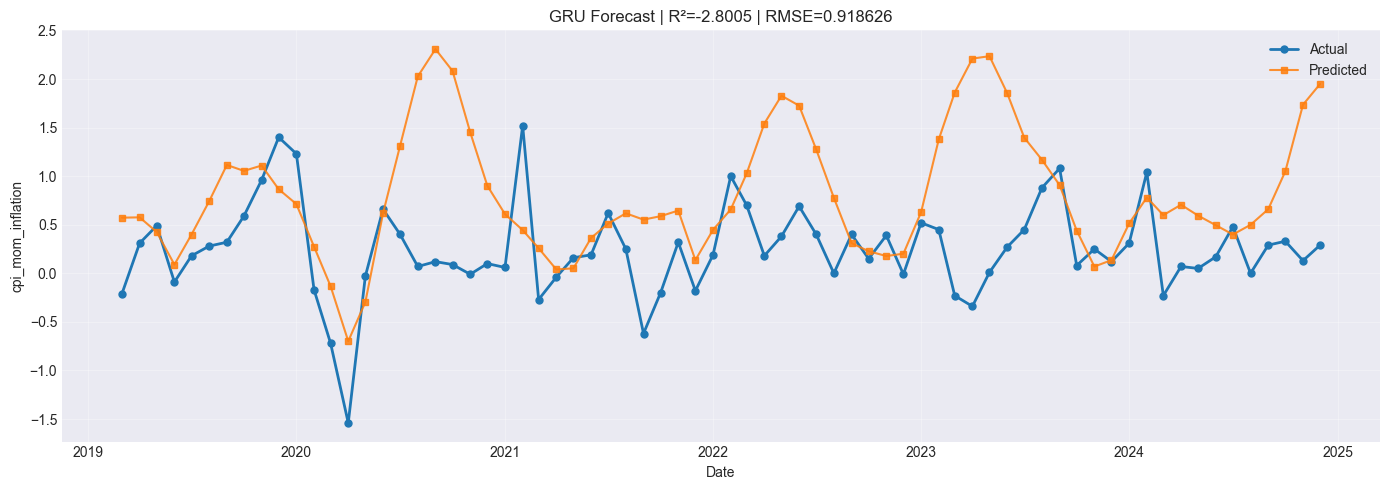

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_test, y_test_actual, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(dates_test, y_pred, "s-", label="Predicted", markersize=4, linewidth=1.5, alpha=0.85)

ax.set_title(f"GRU Forecast | R²={r2:.4f} | RMSE={rmse:.6f}")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "forecast.png"), dpi=150)
plt.show()

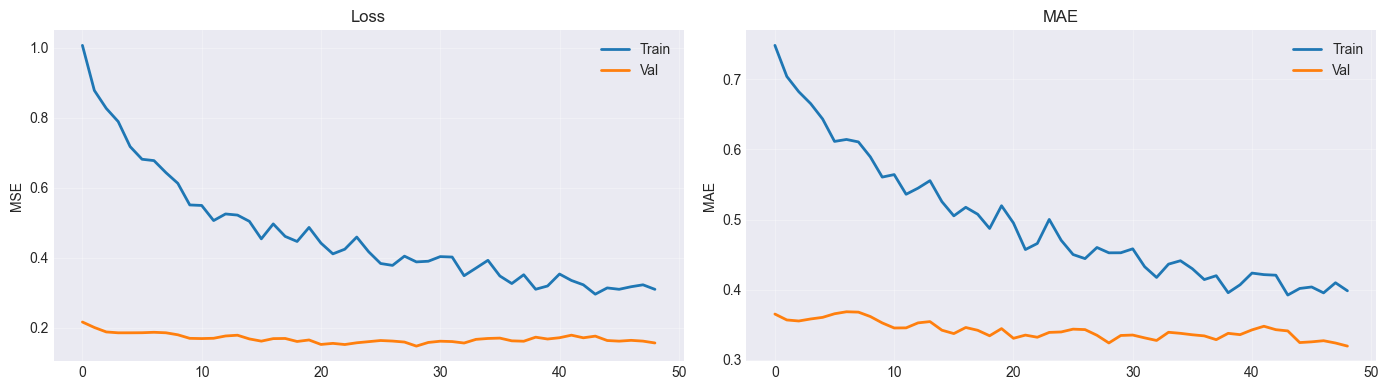

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history["loss"], label="Train", linewidth=2)
ax1.plot(history.history["val_loss"], label="Val", linewidth=2)
ax1.set_title("Loss")
ax1.set_ylabel("MSE")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["mae"], label="Train", linewidth=2)
ax2.plot(history.history["val_mae"], label="Val", linewidth=2)
ax2.set_title("MAE")
ax2.set_ylabel("MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training.png"), dpi=150)
plt.show()

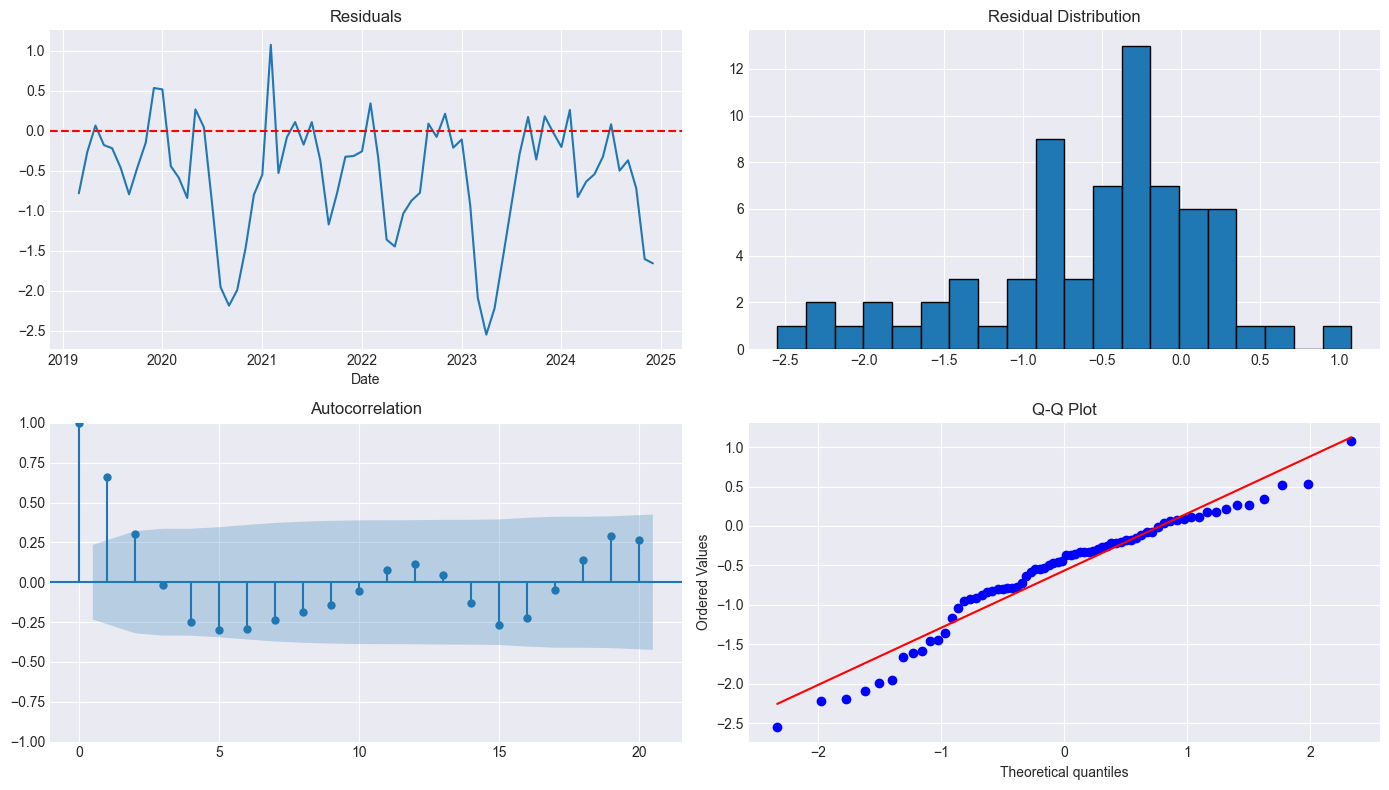

Residual mean: -0.565820
Residual std:  0.723687
Jarque-Bera p-value: 0.045070


In [12]:
residuals = y_test_actual - y_pred

max_lags = min(20, len(residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(dates_test, residuals)
axes[0, 0].axhline(0, color="r", linestyle="--")
axes[0, 0].set_title("Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(residuals, lags=max_lags, ax=axes[1, 0])

stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "residuals.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)

print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")


CẢI THIỆN MÔ HÌNH 

Improved model setup
Target column: cpi_mom_inflation
Target included in features: True
Number of input features: 9
Features: ['cpi_mom_inflation', 'dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']

Sequence creation
X shape: (347, 12, 9)
y shape: (347,)

Leakage check
X end date example: 1996-01-01
y date example:     1996-02-01
Correct if X end date is before y date.

Time split
Train: (242, 12, 9), 1996-02-01 to 2016-03-01
Val:   (35, 12, 9), 2016-04-01 to 2019-02-01
Test:  (70, 12, 9), 2019-03-01 to 2024-12-01


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 12, 32)         │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 12, 32)         │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 16)             │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,913 (27.00 KB)

 Trainable params: 6,913 (27.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.7934 - mae: 1.2138 - val_loss: 0.3022 - val_mae: 0.6337 - learning_rate: 7.0000e-04
Epoch 2/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5354 - mae: 0.9122 - val_loss: 0.2468 - val_mae: 0.5688 - learning_rate: 7.0000e-04
Epoch 3/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4560 - mae: 0.8026 - val_loss: 0.2236 - val_mae: 0.5546 - learning_rate: 7.0000e-04
Epoch 4/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4051 - mae: 0.7498 - val_loss: 0.1989 - val_mae: 0.5251 - learning_rate: 7.0000e-04
Epoch 5/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3694 - mae: 0.7118 - val_loss: 0.1876 - val_mae: 0.5098 - learning_rate: 7.0000e-04
Epoch 6/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3753 - mae: 0.7228 - val_loss: 0.1760 - val_mae: 0.4940 - learning_rate: 7.0000e-04
Epoch 7/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3732 - mae: 0.7134 - val_loss: 0.1696 - val_mae: 0.4758 - learnin

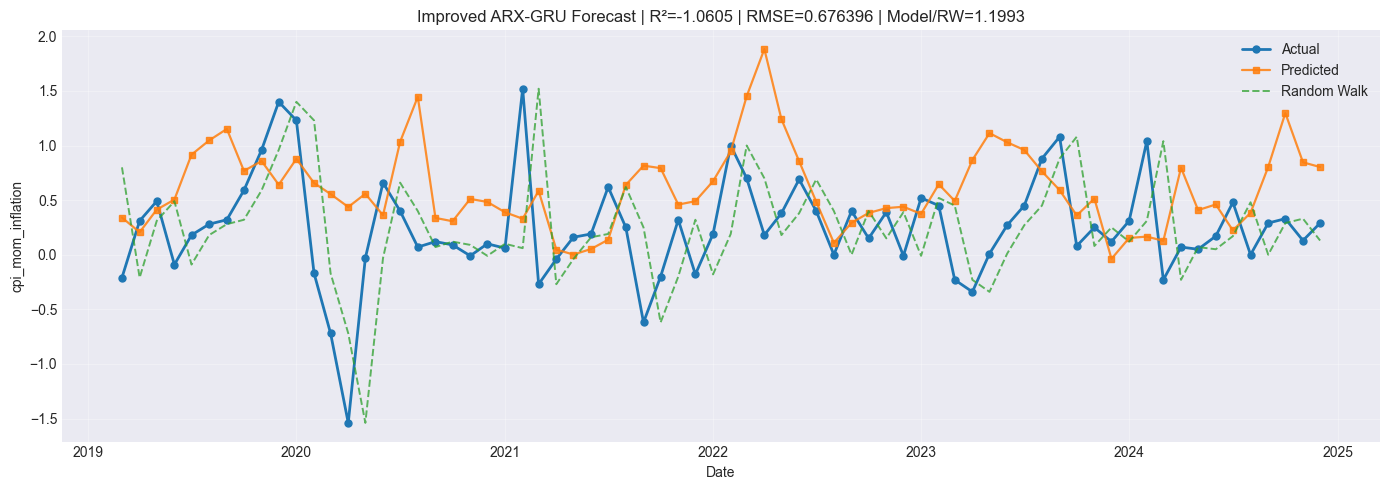

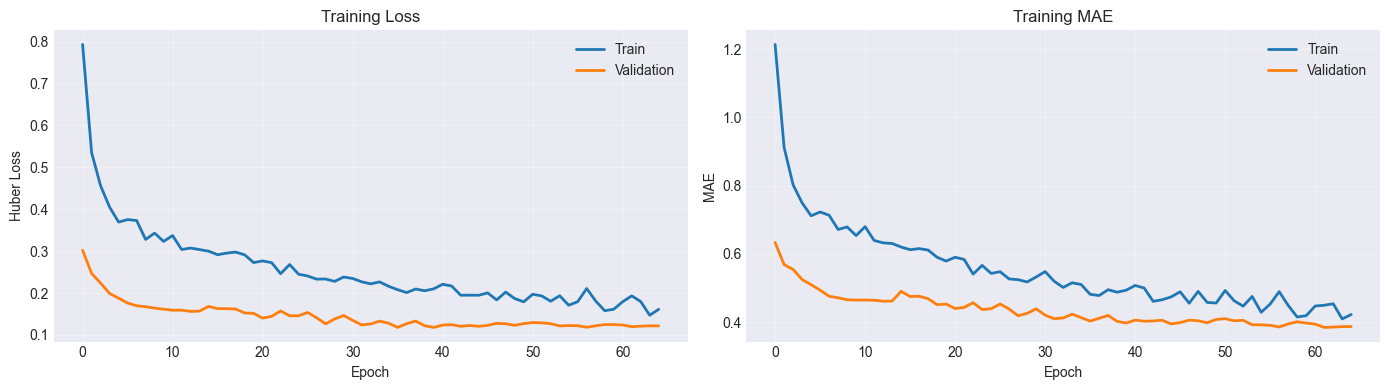


Residual diagnostics
Residual mean: -0.361356
Residual std:  0.571781


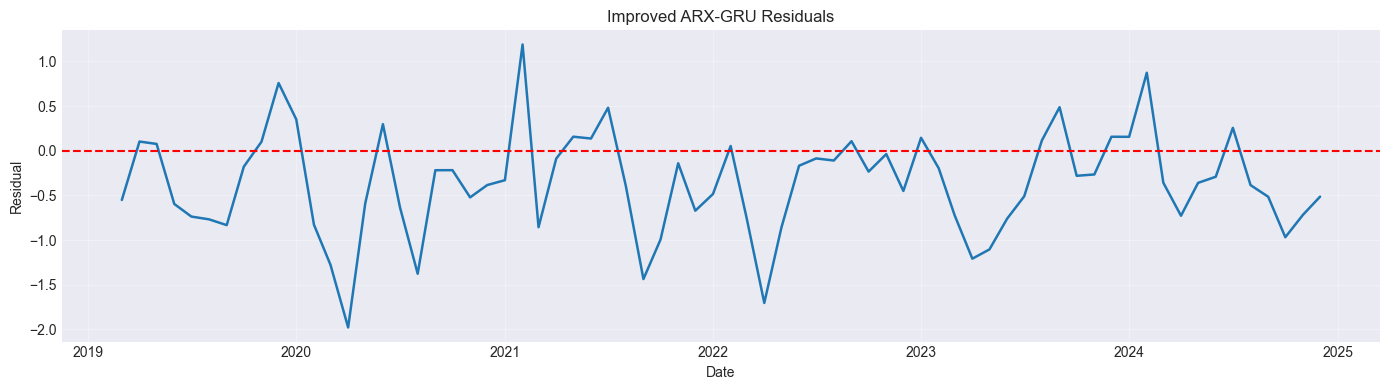

In [13]:
from sklearn.preprocessing import RobustScaler
feature_cols_improved = list(df.columns)

print("Improved model setup")
print(f"Target column: {target_col}")
print(f"Target included in features: {target_col in feature_cols_improved}")
print(f"Number of input features: {len(feature_cols_improved)}")
print(f"Features: {feature_cols_improved}")

def create_supervised_sequences(df, target_col, feature_cols, window=12, horizon=1):
    X, y, dates = [], [], []

    for i in range(window, len(df) - horizon + 1):
        # X: past window months only
        X.append(df[feature_cols].iloc[i-window:i].values)

        # y: next month target
        y.append(df[target_col].iloc[i + horizon - 1])
        dates.append(df.index[i + horizon - 1])

    return np.array(X), np.array(y), pd.Index(dates)


X, y, y_dates = create_supervised_sequences(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols_improved,
    window=12,
    horizon=horizon
)

print("\nSequence creation")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Leakage check
sample_i = 12
print("\nLeakage check")
print(f"X end date example: {df.index[sample_i-1].date()}")
print(f"y date example:     {df.index[sample_i].date()}")
print("Correct if X end date is before y date.")


n = len(X)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train, dates_train = X[:train_end], y[:train_end], y_dates[:train_end]
X_val, y_val, dates_val = X[train_end:val_end], y[train_end:val_end], y_dates[train_end:val_end]
X_test, y_test, dates_test = X[val_end:], y[val_end:], y_dates[val_end:]

print("\nTime split")
print(f"Train: {X_train.shape}, {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Val:   {X_val.shape}, {dates_val[0].date()} to {dates_val[-1].date()}")
print(f"Test:  {X_test.shape}, {dates_test[0].date()} to {dates_test[-1].date()}")


n_train, p, d = X_train.shape

# RobustScaler is often better for macro/financial variables with outliers
x_scaler = RobustScaler()
y_scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, d)
X_val_2d = X_val.reshape(-1, d)
X_test_2d = X_test.reshape(-1, d)

X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test_2d).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.losses import Huber
def build_improved_gru(window, n_features, lr=0.0007):
    model = Sequential([
        GRU(
            32,
            input_shape=(window, n_features),
            return_sequences=True
        ),
        LayerNormalization(),
        Dropout(0.10),

        GRU(
            16,
            return_sequences=False
        ),
        LayerNormalization(),
        Dropout(0.10),

        Dense(16, activation="relu"),
        Dropout(0.05),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=Huber(delta=1.0),
        metrics=["mae"]
    )

    return model


model_improved = build_improved_gru(
    window=12,
    n_features=len(feature_cols_improved),
    lr=0.0007
)

model_improved.summary()


callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

history_improved = model_improved.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=250,
    batch_size=16,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)


y_pred_scaled = model_improved.predict(X_test_scaled, verbose=0).ravel()
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_actual = y_test.copy()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

y_rw = df[target_col].shift(1).reindex(dates_test).values
mask = ~np.isnan(y_rw)

rmse_rw = np.sqrt(mean_squared_error(y_test_actual[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test_actual[mask], y_rw[mask])
vs_rw = rmse / rmse_rw if rmse_rw > 0 else np.nan

print("\n" + "="*70)
print("IMPROVED ARX-GRU TEST RESULTS")
print("="*70)
print(f"R²:                 {r2:.4f}")
print(f"RMSE:               {rmse:.6f}")
print(f"MAE:                {mae:.6f}")
print(f"Random Walk RMSE:   {rmse_rw:.6f}")
print(f"Random Walk MAE:    {mae_rw:.6f}")
print(f"Model / RW RMSE:    {vs_rw:.4f}")
print("="*70)

if vs_rw < 1:
    print("Interpretation: The improved model beats Random Walk by RMSE.")
else:
    print("Interpretation: The improved model does not beat Random Walk by RMSE.")


fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_test, y_test_actual, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(dates_test, y_pred, "s-", label="Predicted", markersize=4, linewidth=1.6, alpha=0.85)
ax.plot(dates_test[mask], y_rw[mask], "--", label="Random Walk", linewidth=1.4, alpha=0.75)

ax.set_title(f"Improved ARX-GRU Forecast | R²={r2:.4f} | RMSE={rmse:.6f} | Model/RW={vs_rw:.4f}")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "improved_arx_gru_forecast.png"), dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_improved.history["loss"], label="Train", linewidth=2)
axes[0].plot(history_improved.history["val_loss"], label="Validation", linewidth=2)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Huber Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_improved.history["mae"], label="Train", linewidth=2)
axes[1].plot(history_improved.history["val_mae"], label="Validation", linewidth=2)
axes[1].set_title("Training MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "improved_arx_gru_training.png"), dpi=150)
plt.show()


residuals = y_test_actual - y_pred

print("\nResidual diagnostics")
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")

plt.figure(figsize=(14, 4))
plt.plot(dates_test, residuals, linewidth=1.8)
plt.axhline(0, color="red", linestyle="--")
plt.title("Improved ARX-GRU Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "improved_arx_gru_residuals.png"), dpi=150)
plt.show()